In [44]:
import pandas as pd
df=pd.read_csv("food_data_set.csv")
df.head()

,Order_ID,Order_Date,Order_Time,Location,Food_Item,Quantity,Total_Amount
0,1,2026-06-13,10:01,Coimbatore,Fried Rice,2,300
1,2,2026-02-05,10:43,Salem,Paneer Butter Masala,1,190
2,3,2026-04-19,08:01,Coimbatore,Pizza,2,500
3,4,2026-05-10,07:35,Trichy,Dosa,5,400
4,5,2026-02-26,21:37,Tirunelveli,Fried Rice,1,150


In [45]:
df.tail()

,Order_ID,Order_Date,Order_Time,Location,Food_Item,Quantity,Total_Amount
995,996,2026-06-02,21:40,Salem,Idli,4,200
996,997,2026-06-13,16:58,Salem,Noodles,4,560
997,998,2026-02-28,09:28,Trichy,Fried Rice,3,450
998,999,2026-03-08,11:19,Salem,Biryani,1,180
999,1000,2026-02-04,18:18,Chennai,Chicken Curry,5,1000


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Order_ID      1000 non-null   int64 
 1   Order_Date    1000 non-null   object
 2   Order_Time    1000 non-null   object
 3   Location      1000 non-null   object
 4   Food_Item     1000 non-null   object
 5   Quantity      1000 non-null   int64 
 6   Total_Amount  1000 non-null   int64 
dtypes: int64(3), object(4)
memory usage: 54.8+ KB


In [47]:
df.columns

Index(['Order_ID', 'Order_Date', 'Order_Time', 'Location', 'Food_Item',
       'Quantity', 'Total_Amount'],
      dtype='object')

In [48]:
df.describe()

,Order_ID,Quantity,Total_Amount
count,1000.000000,1000.000000,1000.000000
mean,500.500000,3.049000,437.180000
std,288.819436,1.434802,282.660122
min,1.000000,1.000000,50.000000
25%,250.750000,2.000000,200.000000
50%,500.500000,3.000000,360.000000
75%,750.250000,4.000000,600.000000
max,1000.000000,5.000000,1250.000000


In [49]:
df.isnull().sum()

,0
Order_ID,0
Order_Date,0
Order_Time,0
Location,0
Food_Item,0
Quantity,0
Total_Amount,0


Peak Order Times

In [50]:
df['Order_Time']=pd.to_datetime(df['Order_Time'])
df['Hour']=df['Order_Time']
df['Hour'].value_counts()

/tmp/ipykernel_2701/759665965.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Order_Time']=pd.to_datetime(df['Order_Time'])


,count
Hour,
2026-06-18 12:23:00,5
2026-06-18 11:36:00,5
2026-06-18 19:23:00,5
2026-06-18 19:05:00,5
2026-06-18 19:55:00,4
...,...
2026-06-18 10:05:00,1
2026-06-18 21:37:00,1
2026-06-18 07:35:00,1


Most Popular Dishes

In [51]:
top_dishes=df['Food_Item'].value_counts().head(10)
print(top_dishes)


Food_Item
Parotta                 118
Fried Rice              114
Noodles                 109
Pizza                   103
Idli                     97
Paneer Butter Masala     96
Chicken Curry            96
Burger                   94
Dosa                     92
Biryani                  81
Name: count, dtype: int64


Food Category Analysis

In [52]:
df['Category']=df['Food_Item']
category_count=df['Category'].value_counts()
print("Food Category Analysis:")
print(category_count)

Food Category Analysis:
Category
Parotta                 118
Fried Rice              114
Noodles                 109
Pizza                   103
Idli                     97
Paneer Butter Masala     96
Chicken Curry            96
Burger                   94
Dosa                     92
Biryani                  81
Name: count, dtype: int64


Location Wise Orders

In [53]:
location_orders=df['Location'].value_counts()
print(location_orders)

Location
Erode          165
Coimbatore     147
Tirunelveli    143
Madurai        143
Salem          142
Trichy         138
Chennai        122
Name: count, dtype: int64


Total Revenue

In [54]:
total_revenue=df['Total_Amount'].sum()
print("Total Revenue:",total_revenue)

Total Revenue: 437180


VISUALIZATION

Peak Order Times

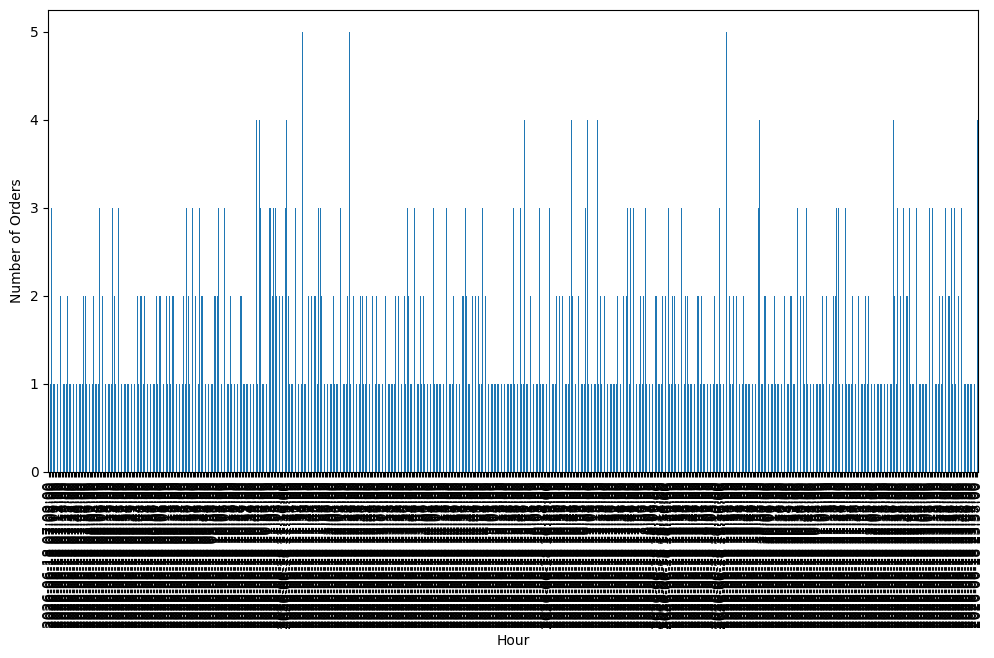

In [55]:
import matplotlib.pyplot as plt
peak_orders=df.groupby('Hour').size()
plt.figure(figsize=(12,6))
peak_orders.plot(kind='bar')
plt.xlabel('Hour')
plt.ylabel('Number of Orders')
plt.show()

Most Popular Dishes

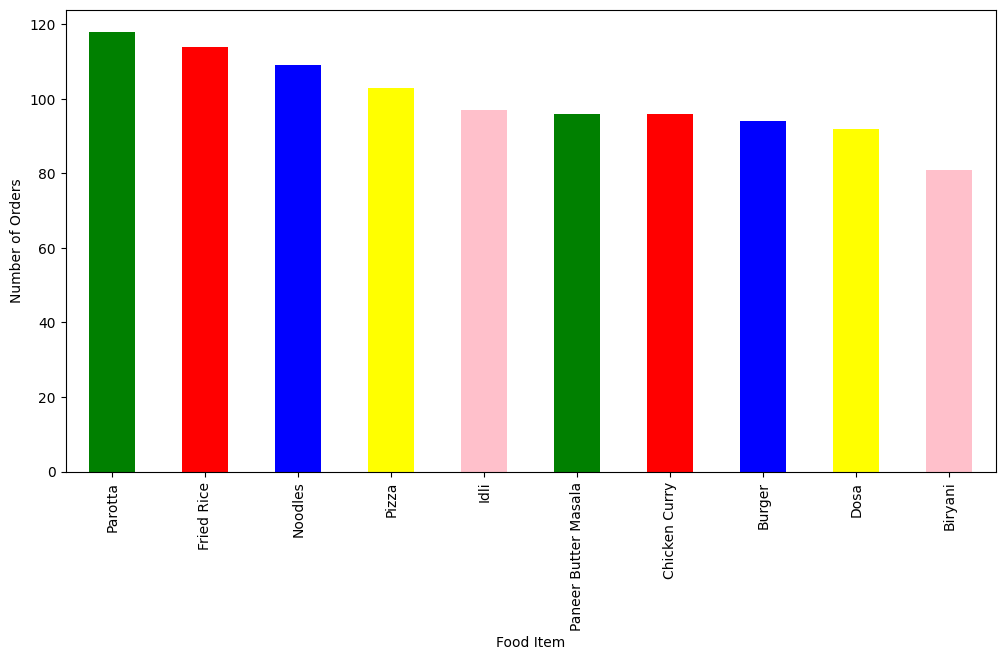

In [56]:
popular_dishes=df['Food_Item'].value_counts().head(10)
plt.figure(figsize=(12,6))
popular_dishes.plot(kind='bar',color=['green','red','blue','yellow','pink'])
plt.xlabel('Food Item')
plt.ylabel('Number of Orders')
plt.show()

Location Wise Orders

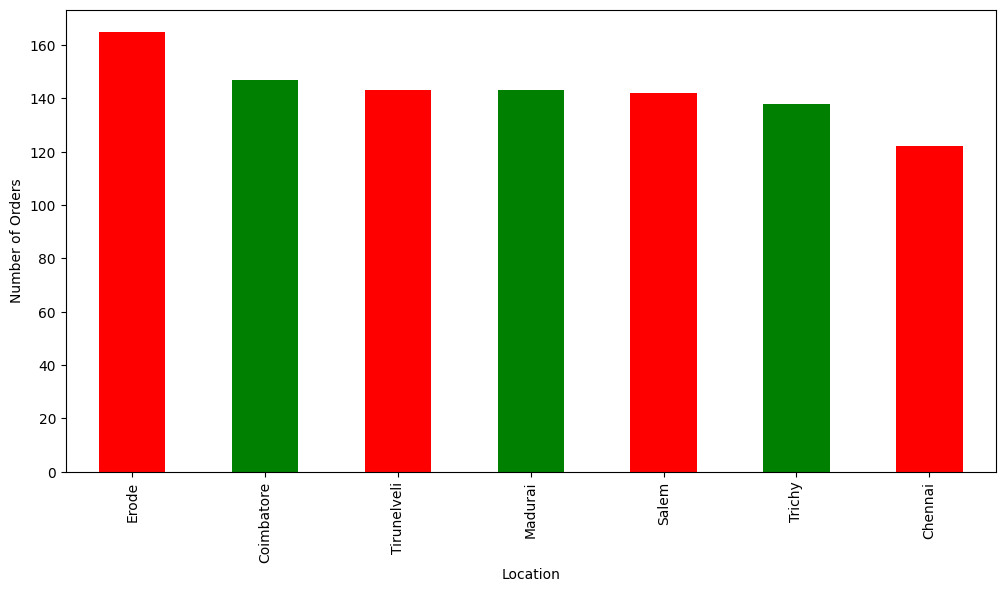

In [57]:
location_orders=df['Location'].value_counts()
plt.figure(figsize=(12,6))
location_orders.plot(kind='bar',color=['red','green'])
plt.xlabel('Location')
plt.ylabel('Number of Orders')
plt.show()

Total Revenue

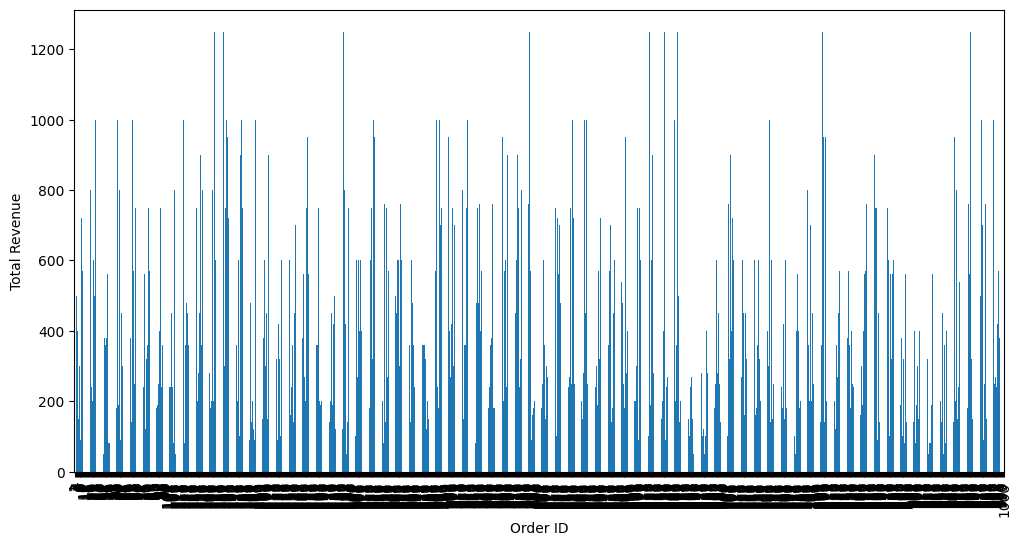

In [58]:
total_revenue=df.groupby('Order_ID')['Total_Amount'].sum()
plt.figure(figsize=(12,6))
total_revenue.plot(kind='bar')
plt.xlabel('Order ID')
plt.ylabel('Total Revenue')
plt.show()

Food Category Perfromence

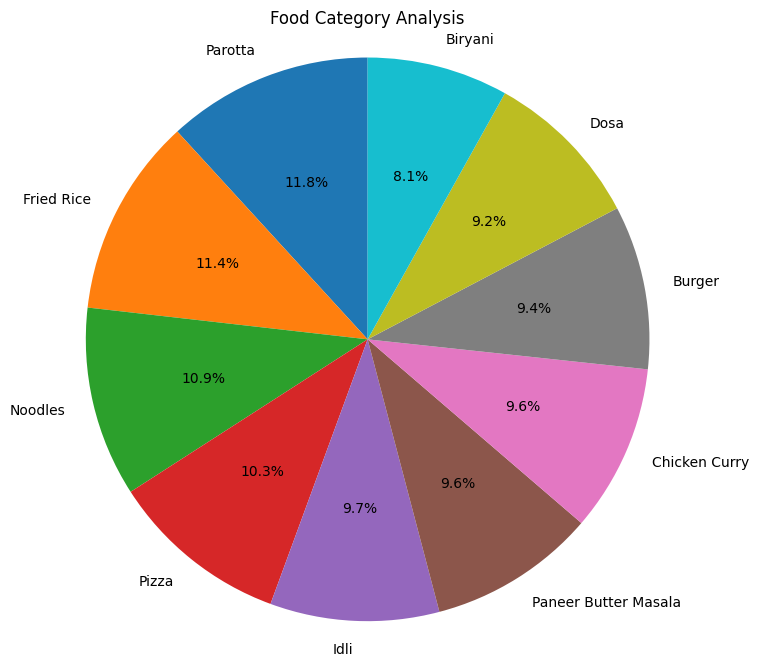

In [59]:
plt.figure(figsize=(8,8))
plt.pie(
    category_count,
    labels=category_count.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Food Category Analysis")
plt.axis('equal')
plt.show()